# H1V2 MPC SQUAT

The idea is to do a squat movement with h1v2. This time, reusing OCP computed on page 3, i want to simulate physics and solve the OCP along the movement.
    

In [20]:
# import robot_loader from scripts
import pinocchio as pin
import crocoddyl
import os
import numpy as np
from scripts.robot_loader import *
import meshcat.geometry as mg
import matplotlib.pyplot as plt

# load model on Meshcat
model, collision_model, visual_model, robot_visualizer, viz = launch_visualization()

print(f"--- Pinocchio model datas ---")
print(f"Robot name: {model.name}")
print(f"Configuration dimension (nq): {model.nq}")
print(f"Velocity dimension (nv): {model.nv}")

data = model.createData()
robot_visualizer.data = data

# Display some frames
frames_to_display = ["pelvis", "left_ground", "right_ground"]
frame_ids = [model.getFrameId(frame_name) for frame_name in frames_to_display]
robot_visualizer.displayFrames(True, frame_ids)

q0 = pin.neutral(model)
q0[2] = 1.03

robot_visualizer.display(q0)
pin.forwardKinematics(model, data, q0)
pin.updateFramePlacements(model, data)

# get ids for contacts
left_foot_id = model.getFrameId("left_ground")
right_foot_id = model.getFrameId("right_ground")
contact_frame_ids = [left_foot_id, right_foot_id]

--- Searching for robot paths ---
Detected project root directory: /home/cpene/Documents/robot_playground
Asset paths verified.
Detected urdf file: /home/cpene/Documents/robot_playground/robot_models/h1_2/h1_2_handless.urdf
Detected mesh directory: /home/cpene/Documents/robot_playground/robot_models/h1_2
Launching MeshCat...
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7034/static/
Adding a grid to represent the ground.
Loading robot model into Pinocchio...


Gtk-Message: 13:19:26.924: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.


Pinocchio model loaded successfully.
Frame 'left_ground' added successfully.
Frame 'right_ground' added successfully.

Environment is ready !
--- Pinocchio model datas ---
Robot name: h1_2
Configuration dimension (nq): 34
Velocity dimension (nv): 33


In [21]:
# Initial guess
# I want to provide a "valide" command for the first input
v0 = np.zeros(model.nv)
a0 = np.zeros(model.nv)
full_gravity_torques = pin.rnea(model, data, q0, v0, a0)
u0 = full_gravity_torques[6:] # this represent the command to counter gravity.

x0 = np.concatenate([q0, v0]) # This represent initial configuration with v = 0

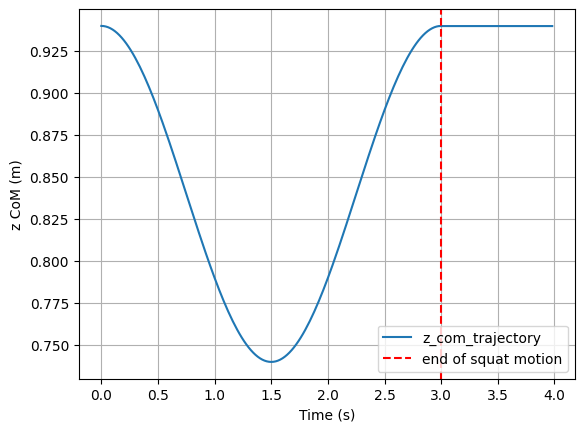

In [22]:
# create trajectory to be used as reference for the CoM
from scripts.build_squat_ocp import *

TRAJECTORY_DURATION = 3.0
HORIZON_LENGTH = 50
OCP_DT = 0.02

reference_com_trajectory = build_squat_com_trajectory(
    model,
    data,
    q0,
    v0,
    traj_duration=TRAJECTORY_DURATION,
    ocp_dt=OCP_DT,
    horizon_length=HORIZON_LENGTH,
    squat_depth=0.20,
)

# Print graph to check trajectory
t_all = np.arange(len(reference_com_trajectory)) * OCP_DT
z_all = reference_com_trajectory[:, 2]

plt.figure()
plt.plot(t_all, z_all, label="z_com_trajectory")
plt.axvline(TRAJECTORY_DURATION, color='r', linestyle='--', label="end of squat motion")
plt.xlabel("Time (s)")
plt.ylabel("z CoM (m)")
plt.grid(True)
plt.legend()
plt.show()

In [23]:
# define parameters 
TRAJECTORY_DURATION = 3.0
HORIZON_LENGTH = 50
OCP_DT = 0.02         # 50 Hz
PHYSICS_DT = 0.001    # 1000 Hz
RATIO_PHYSICS_PER_OCP = int(OCP_DT / PHYSICS_DT)
assert OCP_DT % PHYSICS_DT == 0, "OCP_DT has to be a multiple of PHYSICS_DT"
N_OCP_STEPS = int(TRAJECTORY_DURATION / OCP_DT)

In [24]:
# I want to chain OCP problem in order to solve a small part of a trajectory
from ocp_tools.ocp_builder import OCPBuilder
from ocp_tools.cost_manager import CostModelManager
from ocp_tools.contact_manager import ContactModelManager

x_current = x0.copy()

ocp_save = []
physics_log = [x_current.copy()]

# first guess, used for warm start. it will be updated with result from previous OCP.
xs_init = [x0 for _ in range(HORIZON_LENGTH + 1)]
us_init = [u0 for _ in range(HORIZON_LENGTH)]

# initialize OCP
ocp_build = OCPBuilder(initial_state=x_current,
                                 rmodel=model,
                                 dt=OCP_DT,
                                 horizon_length=HORIZON_LENGTH)

# Create contacts
running_contact_managers = []
for j in range (HORIZON_LENGTH):
    contact_manager = ContactModelManager(ocp_build.state, ocp_build.actuation, model, data)
    contact_manager.add_contact_6D("left_ground") \
                   .add_contact_6D("right_ground")
    running_contact_managers.append(contact_manager)

terminal_contact_manager = ContactModelManager(ocp_build.state, ocp_build.actuation, model, data) \
            .add_contact_6D("left_ground") \
            .add_contact_6D("right_ground")

# DEBUG contacts
#terminal_contact_manager.display_contacts()

# create initial costs - will have to be updated between each OCP
running_cost_managers = []
config_filepath = 'config/H1_squat/regulation_state_weights.yaml'
for j in range (HORIZON_LENGTH):
    cost_manager = CostModelManager(ocp_build.state, ocp_build.actuation)
    cost_manager.add_CoM_position_cost(np.array(reference_com_trajectory[j]), 1e2) \
                  .add_weighted_regulation_state_cost(x_ref=x0, config_filepath=config_filepath, weight=1e-2) \
                  .add_regulation_control_cost(1e-6) \
                  .add_contact_friction_cone_cost(contact_frame_ids, 0.7, 1e-6)

    running_cost_managers.append(cost_manager)

terminal_cost_manager = CostModelManager(ocp_build.state, ocp_build.actuation)
terminal_cost_manager.add_regulation_state_cost(x_ref=x0, weight=1e-2)
                        #.add_CoM_position_cost(np.array(reference_com_trajectory[HORIZON_LENGTH]), 1e2) \
                        #.add_contact_friction_cone_cost(contact_frame_ids, 0.7, 1e-6) 
                        #.add_weighted_regulation_state_cost(x_ref=x0, config_filepath=config_filepath, weight=1e-2) \
                        


# DEBUG costs
#terminal_cost_manager.display_costs()

# Finalize OCP
problem = ocp_build.build(running_cost_managers, terminal_cost_manager, running_contact_managers, terminal_contact_manager)
solver = crocoddyl.SolverFDDP(problem)
MAX_ITER = 500

# these costs with reference will have to change along the movement
running_com_costs = [m.differential.costs.costs['com_position'].cost for m in problem.runningModels]
#running_reg_costs = [m.differential.costs.costs['regulation_weighted_state'].cost for m in problem.runningModels]
#terminal_com_cost = problem.terminalModel.differential.costs.costs['com_position'].cost
#terminal_reg_cost = problem.terminalModel.differential.costs.costs['regulation_weighted_state'].cost


# create phycics simulator with different dt.
simulator_diff_model = problem.runningModels[0].differential
simulator_action_model = crocoddyl.IntegratedActionModelRK(simulator_diff_model, crocoddyl.RKType(4), PHYSICS_DT)
simulator_data = simulator_action_model.createData()


for i in range(N_OCP_STEPS):

    problem.x0 = x_current.copy() 
    #ocp_build.set_initial_state(x_current.copy())

    # update reference for CoM (trajectory to follow)
    current_com_ref = []
    for j in range(HORIZON_LENGTH):
        ref = reference_com_trajectory[i + j]
        running_com_costs[j].residual.reference = ref
        current_com_ref.append(ref.copy())
    #terminal_com_cost.residual.reference = reference_com_trajectory[i + HORIZON_LENGTH]

    # update reference for regulation 
    #for cost in running_reg_costs:
    #    cost.residual.reference = x_current
    #terminal_reg_cost.residual.reference = x_current

    converged = solver.solve(xs_init, us_init, MAX_ITER, False)
    if converged:
        print(f"SUCCESS: FDDP {i} converged in {solver.iter} iterations.")
    else:
        print(f"FAILURE: FDDP {i} did not converge.")
        break

    # get result from solver to be used as next input
    u_optimal = solver.us[0].copy()

    # extract costs for plot
    running_costs = []
    for k in range(HORIZON_LENGTH):
        model_k = problem.runningModels[k]
        data_k = problem.runningDatas[k]
        x_k = solver.xs[k]
        u_k = solver.us[k]
        model_k.calc(data_k, x_k, u_k)
        running_costs.append(data_k.cost)
    terminal_model = problem.terminalModel
    terminal_data = problem.terminalData
    x_T = solver.xs[-1]
    terminal_model.calc(terminal_data, x_T)
    terminal_cost = terminal_data.cost

    J_running = float(np.sum(running_costs))
    J_total_check = J_running + terminal_cost  # pour comparer à solver.cost

    # save ocp informations
    ocp_snapshot = {
        "iteration": i,
        "converged": converged,
        "solver_iterations": solver.iter,
        "cost_total_solver": solver.cost,
        "cost_running_sum": J_running,
        "cost_terminal": terminal_cost,
        "running_costs_per_stage": running_costs,  # taille HORIZON_LENGTH
        "initial_state": x_current.copy(),
        "xs": [x.copy() for x in solver.xs],
        "us": [u.copy() for u in solver.us],
        "com_reference": current_com_ref,
    }
    ocp_save.append(ocp_snapshot)

    # compute physics between two OCP
    for _ in range(RATIO_PHYSICS_PER_OCP):
        simulator_action_model.calc(simulator_data, x_current, u_optimal)
        x_current = simulator_data.xnext.copy()
        physics_log.append(x_current.copy())
    
    # warm start
    xs_init = list(solver.xs)[1:] + [list(solver.xs)[-1]]
    us_init = list(solver.us)[1:] + [list(solver.us)[-1]]

SUCCESS: FDDP 0 converged in 43 iterations.
SUCCESS: FDDP 1 converged in 29 iterations.
SUCCESS: FDDP 2 converged in 27 iterations.
SUCCESS: FDDP 3 converged in 28 iterations.
SUCCESS: FDDP 4 converged in 25 iterations.
SUCCESS: FDDP 5 converged in 31 iterations.
SUCCESS: FDDP 6 converged in 27 iterations.
SUCCESS: FDDP 7 converged in 36 iterations.
SUCCESS: FDDP 8 converged in 30 iterations.
SUCCESS: FDDP 9 converged in 30 iterations.
SUCCESS: FDDP 10 converged in 29 iterations.
SUCCESS: FDDP 11 converged in 30 iterations.
SUCCESS: FDDP 12 converged in 30 iterations.
SUCCESS: FDDP 13 converged in 30 iterations.
SUCCESS: FDDP 14 converged in 31 iterations.
SUCCESS: FDDP 15 converged in 30 iterations.
SUCCESS: FDDP 16 converged in 30 iterations.
SUCCESS: FDDP 17 converged in 34 iterations.
SUCCESS: FDDP 18 converged in 41 iterations.
SUCCESS: FDDP 19 converged in 42 iterations.
SUCCESS: FDDP 20 converged in 46 iterations.
SUCCESS: FDDP 21 converged in 33 iterations.
SUCCESS: FDDP 22 con

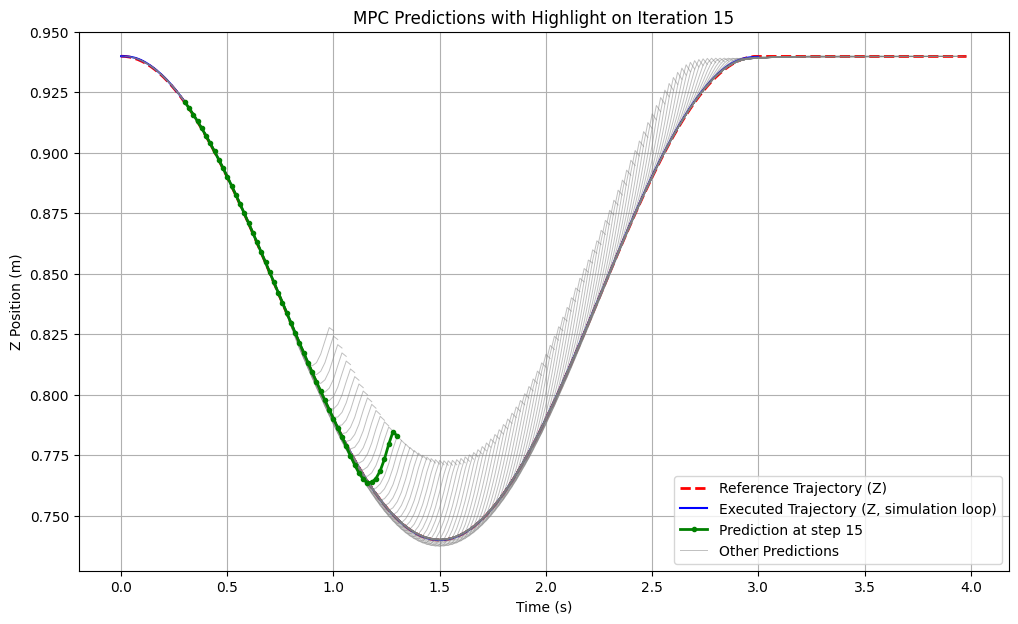

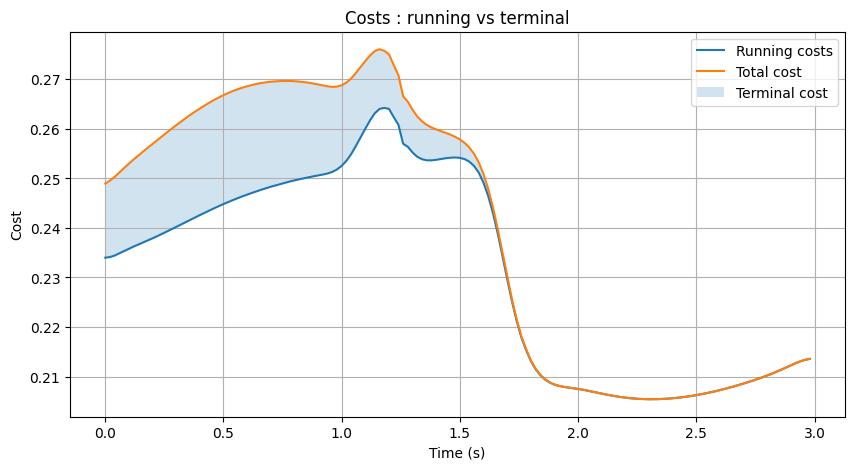

In [25]:
# ==============================================================================
#  Choose an iteration to highlight
# ==============================================================================
ITERATION_TO_HIGHLIGHT = 15
# ==============================================================================

if 'ocp_save' not in locals() or not ocp_save:
    print("'ocp_save' is empty.")

elif ITERATION_TO_HIGHLIGHT >= len(ocp_save):
    print(f"Error : iteration {ITERATION_TO_HIGHLIGHT} is out of range.")

else:
    data_temp = model.createData()

    # Reference trajectory
    z_reference = [com[2] for com in reference_com_trajectory]
    time_axis_reference = np.arange(len(z_reference)) * OCP_DT

    # high frequency trajectory computed by simulator loop
    z_executed_hf = None
    time_axis_executed_hf = None


    data_temp_physics = model.createData()
    z_executed_hf = []

    for x_state in physics_log:
        q = x_state[:model.nq]
        pin.centerOfMass(model, data_temp_physics, q)
        z_executed_hf.append(data_temp_physics.com[0][2])

    z_executed_hf = np.array(z_executed_hf)
    time_axis_executed_hf = np.arange(len(z_executed_hf)) * PHYSICS_DT

    T_max_ref = time_axis_reference[-1]
    valid_idx = time_axis_executed_hf <= T_max_ref
    time_axis_executed_hf = time_axis_executed_hf[valid_idx]
    z_executed_hf = z_executed_hf[valid_idx]


    plt.figure(figsize=(12, 7))
    
    plt.plot(time_axis_reference, z_reference, 'r--', linewidth=2,
             label="Reference Trajectory (Z)")

    if z_executed_hf is not None:
        plt.plot(time_axis_executed_hf, z_executed_hf,
                 'b-', linewidth=1.5,
                 label="Executed Trajectory (Z, simulation loop)")

    for i, snapshot in enumerate(ocp_save):
        time_axis_prediction = (i + np.arange(len(snapshot['xs']))) * OCP_DT

        z_prediction = []
        for x_pred in snapshot['xs']:
            q_pred = x_pred[:model.nq]
            pin.centerOfMass(model, data_temp, q_pred)
            z_prediction.append(data_temp.com[0][2])

        if i == ITERATION_TO_HIGHLIGHT:
            plt.plot(time_axis_prediction, z_prediction,
                     color='green', linestyle='-', linewidth=2,
                     marker='o', markersize=3,
                     label=f"Prediction at step {i}", zorder=10)
        else:
            label = "Other Predictions" if i == 0 else ""
            plt.plot(time_axis_prediction, z_prediction,
                     color='gray', linestyle='-', linewidth=0.7, alpha=0.5,
                     label=label)

    plt.title(f"MPC Predictions with Highlight on Iteration {ITERATION_TO_HIGHLIGHT}")
    plt.xlabel("Time (s)")
    plt.ylabel("Z Position (m)")
    plt.grid(True)

    handles, labels = plt.gca().get_legend_handles_labels()
    order = []
    legend_order = [
        "Reference Trajectory (Z)",
        "Executed Trajectory (Z, simulation loop)",
        f"Prediction at step {ITERATION_TO_HIGHLIGHT}",
        "Other Predictions",
    ]
    for lbl in legend_order:
        if lbl in labels:
            order.append(labels.index(lbl))

    if order:
        plt.legend([handles[idx] for idx in order],
                   [labels[idx] for idx in order])

    plt.show()

# Extract costs 
time_axis = np.arange(len(ocp_save)) * OCP_DT

total_costs   = [snap["cost_total_solver"] for snap in ocp_save]
running_costs = [snap["cost_running_sum"]   for snap in ocp_save]
terminal_costs = [snap["cost_terminal"]    for snap in ocp_save]


plt.figure(figsize=(10, 5))
plt.plot(time_axis, running_costs, label="Running costs")
plt.plot(time_axis, total_costs, label="Total cost")
plt.fill_between(time_axis, running_costs, total_costs, alpha=0.2, label="Terminal cost")
plt.xlabel("Time (s)")
plt.ylabel("Cost")
plt.title("Costs : running vs terminal")
plt.grid(True)
plt.legend()
plt.show()

In [26]:
# Launch the simulation
import time

OCP_DT = 0.033

q_executed_trajectory = [q0.copy()]
for snapshot in ocp_save:
    x_executed = snapshot['xs'][1]
    q_executed = x_executed[:model.nq]
    q_executed_trajectory.append(q_executed)
    
print("Starting animation...")

for q in q_executed_trajectory:
        robot_visualizer.display(q)
        time.sleep(OCP_DT)

print("\nAnimation finished.")


Starting animation...

Animation finished.
